In [2]:
from sysdata.config.configdata import Config
config = Config("private.bybit.bybitconfig.yaml")
config

Config with elements: base_currency, forecast_cap, forecast_div_multiplier, forecast_weights, instrument_div_multiplier, instrument_weights, notional_trading_capital, percentage_vol_target, trading_rules

In [3]:
from private.bybit.bybitsystem import bybitsystem
import warnings; warnings.filterwarnings('ignore')
system = bybitsystem()

Private configuration '/mnt/e/projects/pysystemtrade/private/private_config.yaml' is missing or misconfigured; no problem if running in sim mode


In [4]:
system.accounts.portfolio().stats()

2026-09-07 12:49:32 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-09-07 12:49:32 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-09-07 12:49:32 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-09-07 12:49:32 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-09-07 12:49:32 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-09-07 12:49:32 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'BNB_BYBIT'} Calculating pandl for instrument for BNB_BYBIT
2026-09-07 12:49:32 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'BNB_BYBIT'} Calculating notional position for BNB_BYBIT
2026-09-07 12:49:32 INFO base_system {'stage': 'portfolio', 'instrument_code': 'BNB_BYBIT'} Calculating instrument weights
2026-09-07 12:49:32 DEBUG base_system {'stage': 'portfolio',

[[('min', '-73.55'),
  ('max', '81.98'),
  ('median', '0.06752'),
  ('mean', '0.4643'),
  ('std', '10.11'),
  ('skew', '0.5145'),
  ('ann_mean', '118.9'),
  ('ann_std', '161.7'),
  ('sharpe', '0.7349'),
  ('sortino', '0.9327'),
  ('avg_drawdown', '-100.4'),
  ('time_in_drawdown', '0.9608'),
  ('calmar', '0.5392'),
  ('avg_return_to_drawdown', '1.183'),
  ('avg_loss', '-5.376'),
  ('avg_gain', '5.998'),
  ('gaintolossratio', '1.116'),
  ('profitfactor', '1.179'),
  ('hitrate', '0.5138'),
  ('t_stat', '1.884'),
  ('p_value', '0.05971')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

In [19]:
acc = system.accounts.portfolio()

print(acc.gross.percent.ann_mean())   # брутто годовые %
print(acc.net.percent.ann_mean())     # нетто
print(acc.costs.percent.ann_mean())   # издержки

acc.percent.stats()            # сводка по %

12.181470231729056
11.85195453657729
-0.332678413281596


[[('min', '-7.29'),
  ('max', '8.198'),
  ('median', '0.008005'),
  ('mean', '0.0463'),
  ('std', '1.01'),
  ('skew', '0.5167'),
  ('ann_mean', '11.85'),
  ('ann_std', '16.16'),
  ('sharpe', '0.7332'),
  ('sortino', '0.9274'),
  ('avg_drawdown', '-9.982'),
  ('time_in_drawdown', '0.9608'),
  ('calmar', '0.5338'),
  ('avg_return_to_drawdown', '1.187'),
  ('avg_loss', '-0.5406'),
  ('avg_gain', '0.6007'),
  ('gaintolossratio', '1.111'),
  ('profitfactor', '1.179'),
  ('hitrate', '0.5147'),
  ('t_stat', '1.88'),
  ('p_value', '0.06027')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

<Axes: >

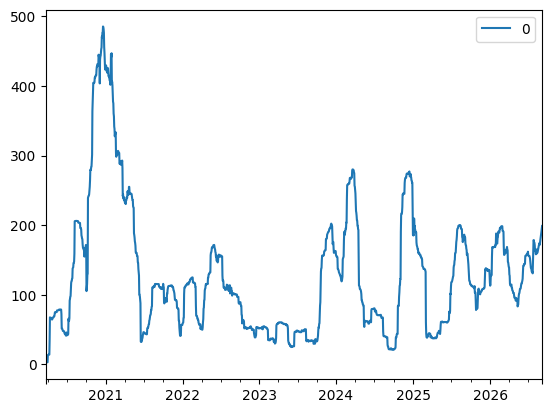

In [17]:
acc.rolling_ann_std().plot()    # скользящий годовой стд

<Axes: >

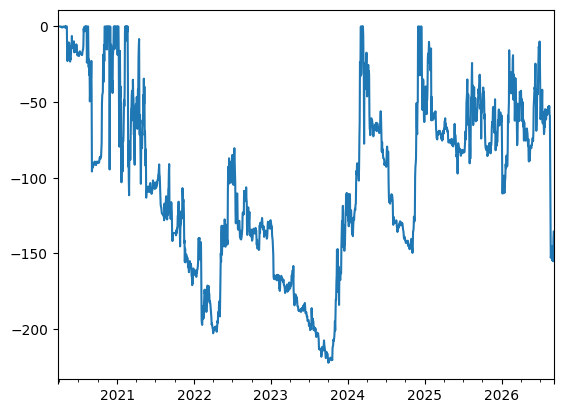

In [16]:
acc.drawdown().plot()           # просадка

<Axes: >

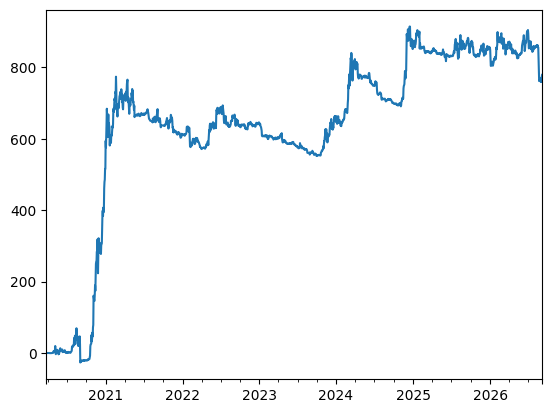

In [15]:
acc.curve().plot()              # кумулятивная кривая

<Axes: xlabel='index'>

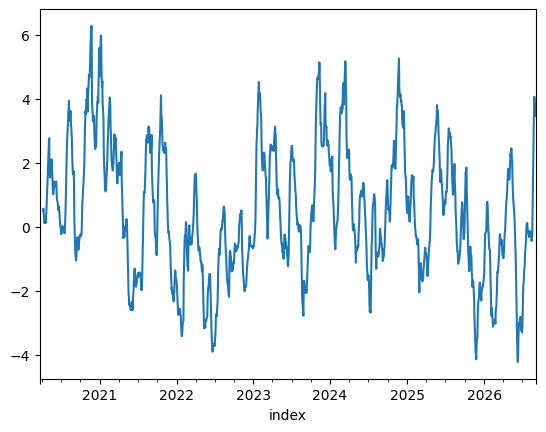

In [26]:
# Промежуточные результаты бектеста
system.rules.get_raw_forecast("BTC_BYBIT", "ewmac8").plot()

In [ ]:
# так можно посмотреть все этапы (stages)
print(system)
# по имени системы посмотреть методыы
system.positionSize.methods()

System base_system with .config, .data, and .stages: accounts, portfolio, positionSize, combForecast, forecastScaleCap, rules, rawdata


['annual_cash_vol_target',
 'avg_abs_forecast',
 'comb_forecast_stage',
 'config',
 'get_average_position_at_subsystem_level',
 'get_base_currency',
 'get_block_value',
 'get_buffers_for_subsystem_position',
 'get_combined_forecast',
 'get_daily_cash_vol_target',
 'get_fx_rate',
 'get_instrument_currency_vol',
 'get_instrument_value_vol',
 'get_notional_trading_capital',
 'get_percentage_vol_target',
 'get_price_volatility',
 'get_subsystem_buffers',
 'get_subsystem_position',
 'get_underlying_price',
 'get_vol_target_dict',
 'methods',
 'rawdata_stage',
 'system_init']

In [31]:
# Или вот так еще:
system.rawdata.methods()  ## works for any stage or data

['all_instruments_in_asset_class',
 'annualised_returns_volatility',
 'annualised_roll',
 'config',
 'daily_annualised_roll',
 'daily_denominator_price',
 'daily_returns',
 'daily_returns_volatility',
 'daily_vol_normalised_price_for_asset_class_with_redundant_instrument_code',
 'data_stage',
 'get_cumulative_daily_vol_normalised_returns',
 'get_daily_percentage_returns',
 'get_daily_percentage_volatility',
 'get_daily_prices',
 'get_daily_vol_normalised_returns',
 'get_fx_for_instrument',
 'get_hourly_prices',
 'get_instrument_raw_carry_data',
 'get_natural_frequency_prices',
 'get_raw_cost_data',
 'get_value_of_block_price_move',
 'hourly_returns',
 'instrument_code',
 'instrument_list',
 'median_carry_for_asset_class',
 'methods',
 'normalised_price_for_asset_class',
 'raw_carry',
 'raw_futures_roll',
 'roll_differentials',
 'rolls_per_year',
 'smoothed_carry',
 'system_init',
 'system_with_redundant_instrument_code_passed']